# HW2 - Random Forest, Gradient Boosted Tree và RF-GBT Stacking cho bài toán dự báo

Notebook này thực hiện đầy đủ yêu cầu bài tập:

1. Cài đặt 2 mô hình trong bài báo HW1: **Random Forest** và **Gradient Boosted Tree**.
2. Chạy trên 2 tập dữ liệu dự báo: **Bike Sharing** và **Air Quality**.
3. Phát triển mô hình kết hợp: **RF-GBT Stacking**.
4. Đánh giá bằng **MAE, RMSE, R²** và thời gian huấn luyện.
5. Vẽ đầy đủ figures riêng cho từng mô hình:
   - Actual vs Predicted.
   - Residual plot.
   - Feature importance cho RF và GBT.
   - So sánh MAE, RMSE, R².

> Cách chạy: Runtime → Run all. Nếu tải dữ liệu vẫn lỗi do mạng, hãy chạy cell upload thủ công ở phần tải dữ liệu.

## 1. Cài đặt và import thư viện

Các thư viện chính:

- `pandas`, `numpy`: xử lý dữ liệu dạng bảng.
- `scikit-learn`: Random Forest, Gradient Boosted Tree, Ridge Regression và metrics.
- `matplotlib`: vẽ biểu đồ.
- `requests`, `zipfile`: tải và giải nén dữ liệu từ UCI.

In [ ]:
# Cài đặt nếu cần. Trên Google Colab, các thư viện này thường đã có sẵn.
# ucimlrepo dùng làm phương án dự phòng nếu tải ZIP trực tiếp bị lỗi.
!pip -q install ucimlrepo

import os
import io
import time
import zipfile
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path('hw1_rf_gbt_stacking')
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
FIG_DIR = RESULTS_DIR / 'figures'

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Thư mục làm việc:', BASE_DIR.resolve())

Thư mục làm việc: /content/hw1_rf_gbt_stacking


## 2. Tải dữ liệu từ UCI - bản đã sửa lỗi 404

Bản notebook cũ dùng các link GitHub mirror, nên có thể gặp lỗi `HTTP Error 404: Not Found`.  
Bản này dùng link UCI cũ nhưng còn phổ biến và ổn định hơn:

- Bike Sharing: `https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip`
- Air Quality: `https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip`

Nếu tải ZIP không được, notebook sẽ thử dùng `ucimlrepo`. Nếu cả hai cách đều lỗi, bạn có thể upload thủ công file `hour.csv` và `AirQualityUCI.csv` vào thư mục `hw1_rf_gbt_stacking/data/`.

In [ ]:
# Đường dẫn file sau khi tải/giải nén
bike_path = DATA_DIR / 'hour.csv'
air_path = DATA_DIR / 'AirQualityUCI.csv'

# Link UCI trực tiếp. Không dùng GitHub raw mirror để tránh 404.
BIKE_ZIP_URLS = [
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip',
    'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
]
AIR_ZIP_URLS = [
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip'
]


def download_file_from_zip(urls, inner_filename, output_path):
    """Tải một file CSV nằm trong ZIP.

    Parameters
    ----------
    urls : list[str]
        Danh sách URL dự phòng.
    inner_filename : str
        Tên file cần lấy trong ZIP, ví dụ 'hour.csv'.
    output_path : Path
        Nơi lưu file CSV sau khi giải nén.
    """
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f'Đã có file: {output_path}')
        return True

    for url in urls:
        try:
            print('\nĐang tải:', url)
            response = requests.get(url, timeout=60)
            response.raise_for_status()

            with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
                print('Các file trong ZIP:', zf.namelist())
                matched = [name for name in zf.namelist() if name.endswith(inner_filename)]
                if not matched:
                    raise FileNotFoundError(f'Không thấy {inner_filename} trong ZIP.')

                with zf.open(matched[0]) as src, open(output_path, 'wb') as dst:
                    dst.write(src.read())

            print('Tải và giải nén thành công:', output_path)
            return True
        except Exception as e:
            print('Không tải được URL này. Lỗi:', repr(e))

    return False


bike_ok = download_file_from_zip(BIKE_ZIP_URLS, 'hour.csv', bike_path)
air_ok = download_file_from_zip(AIR_ZIP_URLS, 'AirQualityUCI.csv', air_path)

print('\nKết quả tải dữ liệu:')
print('Bike Sharing:', bike_ok, '|', bike_path)
print('Air Quality :', air_ok, '|', air_path)


Đang tải: https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
Các file trong ZIP: ['Readme.txt', 'day.csv', 'hour.csv']
Tải và giải nén thành công: hw1_rf_gbt_stacking/data/hour.csv

Đang tải: https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Các file trong ZIP: ['AirQualityUCI.csv', 'AirQualityUCI.xlsx']
Tải và giải nén thành công: hw1_rf_gbt_stacking/data/AirQualityUCI.csv

Kết quả tải dữ liệu:
Bike Sharing: True | hw1_rf_gbt_stacking/data/hour.csv
Air Quality : True | hw1_rf_gbt_stacking/data/AirQualityUCI.csv


### 2.1. Phương án dự phòng bằng `ucimlrepo`

Cell này chỉ cần chạy nếu cell tải ZIP phía trên bị lỗi.  
Thông thường bạn có thể chạy luôn, nếu file đã tồn tại thì cell này không làm gì thêm.

In [ ]:
def fetch_with_ucimlrepo_if_needed():
    """Dự phòng khi tải ZIP trực tiếp thất bại."""
    global bike_ok, air_ok

    try:
        from ucimlrepo import fetch_ucirepo
    except Exception as e:
        print('Không import được ucimlrepo:', e)
        return

    # Bike Sharing UCI id = 275
    if not bike_path.exists() or bike_path.stat().st_size == 0:
        try:
            print('Thử tải Bike Sharing bằng ucimlrepo id=275...')
            bike = fetch_ucirepo(id=275)
            X = bike.data.features.copy()
            y = bike.data.targets.copy() if bike.data.targets is not None else None
            if y is not None:
                bike_df_tmp = pd.concat([X, y], axis=1)
            else:
                bike_df_tmp = X.copy()
            bike_df_tmp.to_csv(bike_path, index=False)
            bike_ok = True
            print('Đã lưu Bike Sharing:', bike_path)
        except Exception as e:
            print('ucimlrepo Bike Sharing lỗi:', repr(e))

    # Air Quality UCI id = 387 theo giao diện mới
    if not air_path.exists() or air_path.stat().st_size == 0:
        try:
            print('Thử tải Air Quality bằng ucimlrepo id=387...')
            air = fetch_ucirepo(id=387)
            X = air.data.features.copy()
            y = air.data.targets.copy() if air.data.targets is not None else None
            if y is not None:
                air_df_tmp = pd.concat([X, y], axis=1)
            else:
                air_df_tmp = X.copy()
            air_df_tmp.to_csv(air_path, index=False)
            air_ok = True
            print('Đã lưu Air Quality:', air_path)
        except Exception as e:
            print('ucimlrepo Air Quality lỗi:', repr(e))

fetch_with_ucimlrepo_if_needed()

print('\nKiểm tra file cuối cùng:')
print('Bike exists:', bike_path.exists(), '| size:', bike_path.stat().st_size if bike_path.exists() else 0)
print('Air exists :', air_path.exists(), '| size:', air_path.stat().st_size if air_path.exists() else 0)


Kiểm tra file cuối cùng:
Bike exists: True | size: 1156736
Air exists : True | size: 785065


### 2.2. Upload thủ công nếu mạng bị chặn

Chỉ dùng cell này nếu cả hai cách trên đều không tải được.  
Bạn upload hai file:

- `hour.csv` cho Bike Sharing.
- `AirQualityUCI.csv` cho Air Quality.

Sau khi upload, notebook sẽ tự lưu vào thư mục `hw1_rf_gbt_stacking/data/`.

In [ ]:
# Chỉ chạy cell này nếu bạn cần upload thủ công trong Colab.
# from google.colab import files
# uploaded = files.upload()
# for name, content in uploaded.items():
#     target = DATA_DIR / name
#     with open(target, 'wb') as f:
#         f.write(content)
#     print('Đã upload:', target)

## 3. Các hàm dùng chung

Phần này định nghĩa:

- `evaluate_regression`: tính MAE, RMSE, R².
- `add_lag_features`: tạo biến trễ và rolling mean.
- `temporal_train_val_test_split`: chia dữ liệu theo thời gian, không shuffle.
- `build_models`: tạo Random Forest và Gradient Boosted Tree.
- `train_stacking_model`: huấn luyện mô hình RF-GBT Stacking đúng quy trình train/validation/test.

In [ ]:
def evaluate_regression(y_true, y_pred):
    """Tính các độ đo hồi quy.

    MAE  : sai số tuyệt đối trung bình, càng nhỏ càng tốt.
    RMSE : căn sai số bình phương trung bình, phạt mạnh lỗi lớn, càng nhỏ càng tốt.
    R2   : mức độ giải thích biến thiên, càng gần 1 càng tốt.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


def add_lag_features(df, target_col, lags=[1, 2, 3, 24], rolling_windows=[3, 24]):
    """Tạo biến trễ và trung bình trượt cho bài toán dự báo.

    Ví dụ với target `cnt`:
    - cnt_lag_1: giá trị cnt ở thời điểm trước đó 1 giờ.
    - cnt_lag_24: giá trị cnt cùng giờ ngày hôm trước.
    - cnt_roll_mean_24: trung bình 24 giờ gần nhất.
    """
    df = df.copy()
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    for window in rolling_windows:
        df[f'{target_col}_roll_mean_{window}'] = df[target_col].shift(1).rolling(window).mean()
    return df


def temporal_train_val_test_split(df, train_size=0.70, val_size=0.15):
    """Chia dữ liệu theo thứ tự thời gian để tránh data leakage."""
    n = len(df)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    return df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]


def build_models():
    """Tạo 2 mô hình gốc.

    Random Forest: nhiều cây độc lập, lấy trung bình dự báo.
    Gradient Boosted Tree: các cây học tuần tự để sửa lỗi.
    """
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    gbt = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=RANDOM_STATE
    )

    return rf, gbt


def train_stacking_model(X_train, y_train, X_val, y_val, X_test):
    """Huấn luyện RF-GBT Stacking.

    Bước 1: RF và GBT học trên train.
    Bước 2: RF và GBT dự báo trên validation.
    Bước 3: Ridge Regression học cách kết hợp 2 dự báo đó.
    Bước 4: RF và GBT được huấn luyện lại trên train + validation.
    Bước 5: Dự báo test và đưa qua meta-model.
    """
    rf, gbt = build_models()

    # Base models học trên train
    rf.fit(X_train, y_train)
    gbt.fit(X_train, y_train)

    # Dự báo trên validation để tạo dữ liệu cho meta-model
    val_pred_rf = rf.predict(X_val)
    val_pred_gbt = gbt.predict(X_val)
    X_meta_val = np.column_stack([val_pred_rf, val_pred_gbt])

    # Meta-model học cách kết hợp RF và GBT
    meta_model = Ridge(alpha=1.0)
    meta_model.fit(X_meta_val, y_val)

    # Huấn luyện lại base models trên train + validation để tận dụng thêm dữ liệu
    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    rf_final, gbt_final = build_models()
    rf_final.fit(X_train_full, y_train_full)
    gbt_final.fit(X_train_full, y_train_full)

    # Dự báo test
    test_pred_rf = rf_final.predict(X_test)
    test_pred_gbt = gbt_final.predict(X_test)
    X_meta_test = np.column_stack([test_pred_rf, test_pred_gbt])
    test_pred_stack = meta_model.predict(X_meta_test)

    return test_pred_stack, rf_final, gbt_final, meta_model

## 4. Hàm vẽ figures

Notebook v4 vẽ riêng từng mô hình, không chỉ vẽ mỗi Stacking:

- Random Forest - Actual vs Predicted.
- Gradient Boosted Tree - Actual vs Predicted.
- RF-GBT Stacking - Actual vs Predicted.
- Residual plot riêng cho từng mô hình.
- Feature importance riêng cho RF và GBT.

In [ ]:
def safe_name(text):
    return text.lower().replace(' ', '_').replace('-', '_').replace('/', '_')


def plot_actual_vs_predicted(y_true, y_pred, dataset_name, model_name, max_points=250):
    """Vẽ đường giá trị thực tế và dự báo."""
    plt.figure(figsize=(12, 4))
    y_true_arr = np.asarray(y_true)[:max_points]
    y_pred_arr = np.asarray(y_pred)[:max_points]
    plt.plot(y_true_arr, label='Actual')
    plt.plot(y_pred_arr, label='Predicted')
    plt.title(f'Actual vs Predicted - {dataset_name} - {model_name}')
    plt.xlabel('Time index')
    plt.ylabel('Target value')
    plt.legend()
    plt.tight_layout()
    path = FIG_DIR / f'{safe_name(dataset_name)}_{safe_name(model_name)}_actual_vs_predicted.png'
    plt.savefig(path, dpi=300)
    plt.show()
    print('Đã lưu:', path)


def plot_residual(y_true, y_pred, dataset_name, model_name, max_points=250):
    """Vẽ residual = actual - predicted."""
    residual = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(12, 4))
    plt.plot(residual[:max_points], label='Residual')
    plt.axhline(0, linestyle='--')
    plt.title(f'Residual Plot - {dataset_name} - {model_name}')
    plt.xlabel('Time index')
    plt.ylabel('Residual')
    plt.legend()
    plt.tight_layout()
    path = FIG_DIR / f'{safe_name(dataset_name)}_{safe_name(model_name)}_residual.png'
    plt.savefig(path, dpi=300)
    plt.show()
    print('Đã lưu:', path)


def plot_feature_importance(model, feature_cols, dataset_name, model_name, top_n=15):
    """Vẽ độ quan trọng biến cho RF hoặc GBT."""
    if not hasattr(model, 'feature_importances_'):
        return
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 5))
    importances.sort_values().plot(kind='barh')
    plt.title(f'Feature Importance - {dataset_name} - {model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    path = FIG_DIR / f'{safe_name(dataset_name)}_{safe_name(model_name)}_feature_importance.png'
    plt.savefig(path, dpi=300)
    plt.show()
    print('Đã lưu:', path)


def plot_metric_bars(results_df, dataset_name, metric):
    """Vẽ biểu đồ so sánh metric cho 3 mô hình."""
    sub = results_df[results_df['Dataset'] == dataset_name]
    plt.figure(figsize=(8, 4))
    plt.bar(sub['Model'], sub[metric])
    plt.title(f'{metric} Comparison - {dataset_name}')
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    path = FIG_DIR / f'{safe_name(dataset_name)}_{safe_name(metric)}_comparison.png'
    plt.savefig(path, dpi=300)
    plt.show()
    print('Đã lưu:', path)

## 5. Tiền xử lý Bike Sharing Dataset

Mục tiêu: dự báo `cnt` ở giờ tiếp theo.

Các cột bị loại:

- `instant`: chỉ là chỉ số dòng.
- `dteday`: sau khi tạo `datetime` thì không cần giữ dạng chuỗi.
- `casual`, `registered`: gây **data leakage** vì `casual + registered = cnt`.

Biến trễ được tạo thêm để mô hình có thông tin quá khứ, ví dụ `cnt_lag_1`, `cnt_lag_24`.

In [ ]:
def load_bike_data(path):
    if not path.exists():
        raise FileNotFoundError(f'Không thấy file Bike Sharing: {path}. Hãy kiểm tra phần tải dữ liệu.')

    df = pd.read_csv(path)

    # Nếu dữ liệu lấy từ ucimlrepo có thể có target trùng tên, loại cột trùng nếu có.
    df = df.loc[:, ~df.columns.duplicated()]

    if 'dteday' in df.columns and 'hr' in df.columns:
        df['datetime'] = pd.to_datetime(df['dteday']) + pd.to_timedelta(df['hr'], unit='h')
    else:
        df['datetime'] = pd.date_range(start='2011-01-01', periods=len(df), freq='h')

    df = df.sort_values('datetime').reset_index(drop=True)

    target_col = 'cnt'
    if target_col not in df.columns:
        # Một số phiên bản ucimlrepo có thể đặt target ở cột cuối.
        print('Các cột hiện có:', df.columns.tolist())
        raise ValueError('Bike Sharing cần có cột cnt làm target.')

    drop_cols = [c for c in ['instant', 'dteday', 'casual', 'registered'] if c in df.columns]
    df = df.drop(columns=drop_cols)

    # Đảm bảo các cột numeric đúng kiểu
    for col in df.columns:
        if col != 'datetime':
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = add_lag_features(df, target_col=target_col)
    df['target_next'] = df[target_col].shift(-1)
    df = df.dropna().reset_index(drop=True)
    return df

bike_df = load_bike_data(bike_path)
print('Bike shape:', bike_df.shape)
display(bike_df.head())

Bike shape: (17354, 21)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,windspeed,cnt,datetime,cnt_lag_1,cnt_lag_2,cnt_lag_3,cnt_lag_24,cnt_roll_mean_3,cnt_roll_mean_24,target_next
0,1,0,1,0,0,0,0,2,0.46,0.4545,...,0.2985,17,2011-01-02 00:00:00,39.0,28.0,34.0,16.0,33.666667,41.041667,17.0
1,1,0,1,1,0,0,0,2,0.44,0.4394,...,0.2537,17,2011-01-02 01:00:00,17.0,39.0,28.0,40.0,28.000000,41.083333,9.0
2,1,0,1,2,0,0,0,2,0.42,0.4242,...,0.2836,9,2011-01-02 02:00:00,17.0,17.0,39.0,32.0,24.333333,40.125000,6.0
3,1,0,1,3,0,0,0,2,0.46,0.4545,...,0.1940,6,2011-01-02 03:00:00,9.0,17.0,17.0,13.0,14.333333,39.166667,3.0
4,1,0,1,4,0,0,0,2,0.46,0.4545,...,0.1940,3,2011-01-02 04:00:00,6.0,9.0,17.0,1.0,10.666667,38.875000,2.0


## 6. Tiền xử lý Air Quality Dataset

Mục tiêu: dự báo `CO(GT)` ở giờ tiếp theo.

Điểm quan trọng:

- File gốc thường dùng dấu `;` để phân tách và dấu `,` cho số thập phân.
- Missing values được mã hóa bằng `-200`, cần chuyển thành `NaN`.
- Dữ liệu được nội suy tuyến tính theo thời gian để giữ tính liên tục.

In [ ]:
def load_air_quality_data(path):
    if not path.exists():
        raise FileNotFoundError(f'Không thấy file Air Quality: {path}. Hãy kiểm tra phần tải dữ liệu.')

    # Thử đọc định dạng UCI gốc trước.
    try:
        df = pd.read_csv(path, sep=';', decimal=',', engine='python')
    except Exception:
        df = pd.read_csv(path)

    df = df.dropna(axis=1, how='all')
    df = df.dropna(axis=0, how='all')
    df = df.loc[:, ~df.columns.duplicated()]

    # Tạo datetime nếu có Date và Time
    if 'Date' in df.columns and 'Time' in df.columns:
        df['datetime'] = pd.to_datetime(
            df['Date'].astype(str) + ' ' + df['Time'].astype(str),
            format='%d/%m/%Y %H.%M.%S',
            errors='coerce'
        )
    else:
        df['datetime'] = pd.date_range(start='2004-03-10', periods=len(df), freq='h')

    df = df.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

    # Chuyển numeric. Nếu dữ liệu bị đọc thành object, thay dấu phẩy bằng dấu chấm.
    for col in df.columns:
        if col not in ['Date', 'Time', 'datetime']:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Missing value trong bộ này được mã hóa bằng -200.
    df = df.replace(-200, np.nan)

    target_col = 'CO(GT)'
    if target_col not in df.columns:
        print('Các cột hiện có:', df.columns.tolist())
        raise ValueError('Air Quality cần có cột CO(GT) làm target.')

    # Bỏ dòng thiếu target, nội suy các biến numeric
    df = df.dropna(subset=[target_col])
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].interpolate(method='linear')
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    # Thêm biến thời gian
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month

    df = add_lag_features(df, target_col=target_col)
    df['target_next'] = df[target_col].shift(-1)
    df = df.dropna().reset_index(drop=True)
    return df

air_df = load_air_quality_data(air_path)
print('Air Quality shape:', air_df.shape)
display(air_df.head())

Air Quality shape: (7649, 26)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),...,hour,dayofweek,month,CO(GT)_lag_1,CO(GT)_lag_2,CO(GT)_lag_3,CO(GT)_lag_24,CO(GT)_roll_mean_3,CO(GT)_roll_mean_24,target_next
0,11/03/2004,19.00.00,6.9,1776.0,461.0,27.4,1488.0,383.0,702.0,172.0,...,19,3,3,4.8,2.9,2.2,2.6,3.300000,1.829167,6.1
1,11/03/2004,20.00.00,6.1,1640.0,401.0,24.0,1404.0,351.0,743.0,165.0,...,20,3,3,6.9,4.8,2.9,2.0,4.866667,2.008333,3.9
2,11/03/2004,21.00.00,3.9,1313.0,197.0,12.8,1076.0,240.0,957.0,136.0,...,21,3,3,6.1,6.9,4.8,2.2,5.933333,2.179167,1.5
3,11/03/2004,22.00.00,1.5,965.0,61.0,4.7,749.0,94.0,1325.0,85.0,...,22,3,3,3.9,6.1,6.9,2.2,5.633333,2.250000,1.0
4,11/03/2004,23.00.00,1.0,913.0,26.0,2.6,629.0,47.0,1565.0,53.0,...,23,3,3,1.5,3.9,6.1,1.6,3.833333,2.220833,1.7


## 7. Hàm chạy thực nghiệm trên một dataset

Hàm này tự động:

1. Chọn feature numeric.
2. Chia dữ liệu theo thời gian thành train/validation/test.
3. Huấn luyện Random Forest.
4. Huấn luyện Gradient Boosted Tree.
5. Huấn luyện RF-GBT Stacking.
6. Tính MAE, RMSE, R².
7. Vẽ figures riêng cho từng mô hình.

In [ ]:
def run_experiment(df, dataset_name, target_col='target_next', exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    # Chỉ giữ cột numeric làm feature, tránh datetime/text.
    exclude = set(exclude_cols + [target_col])
    feature_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

    train_df, val_df, test_df = temporal_train_val_test_split(df)

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_val = val_df[feature_cols]
    y_val = val_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    print('\n' + '='*80)
    print('Dataset:', dataset_name)
    print('Số dòng train/val/test:', len(train_df), len(val_df), len(test_df))
    print('Số features:', len(feature_cols))

    results = []
    predictions = {}
    fitted_models = {}

    # Baseline dùng train + validation để đánh giá công bằng trên test.
    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    # 1. Random Forest
    rf, gbt = build_models()
    start = time.time()
    rf.fit(X_train_full, y_train_full)
    fit_time = time.time() - start
    pred_rf = rf.predict(X_test)
    results.append({'Dataset': dataset_name, 'Model': 'Random Forest', **evaluate_regression(y_test, pred_rf), 'Fit time (s)': fit_time})
    predictions['Random Forest'] = pred_rf
    fitted_models['Random Forest'] = rf

    # 2. Gradient Boosted Tree
    start = time.time()
    gbt.fit(X_train_full, y_train_full)
    fit_time = time.time() - start
    pred_gbt = gbt.predict(X_test)
    results.append({'Dataset': dataset_name, 'Model': 'Gradient Boosted Tree', **evaluate_regression(y_test, pred_gbt), 'Fit time (s)': fit_time})
    predictions['Gradient Boosted Tree'] = pred_gbt
    fitted_models['Gradient Boosted Tree'] = gbt

    # 3. RF-GBT Stacking
    start = time.time()
    pred_stack, rf_final, gbt_final, meta_model = train_stacking_model(X_train, y_train, X_val, y_val, X_test)
    fit_time = time.time() - start
    results.append({'Dataset': dataset_name, 'Model': 'RF-GBT Stacking', **evaluate_regression(y_test, pred_stack), 'Fit time (s)': fit_time})
    predictions['RF-GBT Stacking'] = pred_stack
    fitted_models['RF-GBT Stacking'] = meta_model

    results_df = pd.DataFrame(results)
    display(results_df)

    # Figures riêng cho từng mô hình: RF, GBT, Stacking
    for model_name, pred in predictions.items():
        plot_actual_vs_predicted(y_test, pred, dataset_name, model_name)
        plot_residual(y_test, pred, dataset_name, model_name)

    # Feature importance riêng cho RF và GBT
    plot_feature_importance(rf, feature_cols, dataset_name, 'Random Forest')
    plot_feature_importance(gbt, feature_cols, dataset_name, 'Gradient Boosted Tree')

    return results_df, y_test, predictions, fitted_models, feature_cols

## 8. Chạy thực nghiệm trên Bike Sharing


Dataset: Bike Sharing
Số dòng train/val/test: 12147 2603 2604
Số features: 19


,Dataset,Model,MAE,RMSE,R2,Fit time (s)
0,Bike Sharing,Random Forest,27.378685,45.735348,0.954395,62.179266
1,Bike Sharing,Gradient Boosted Tree,34.449464,53.006898,0.938741,13.237331
2,Bike Sharing,RF-GBT Stacking,28.255780,46.205964,0.953452,109.665990


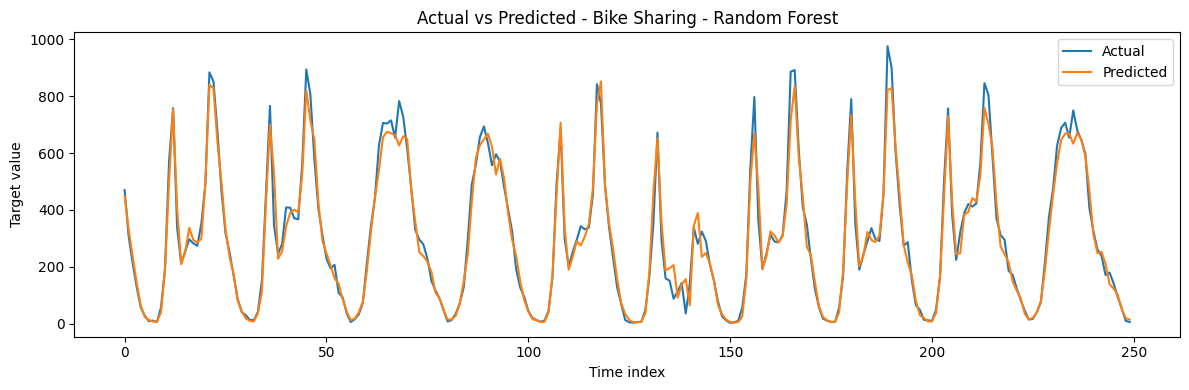

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_random_forest_actual_vs_predicted.png


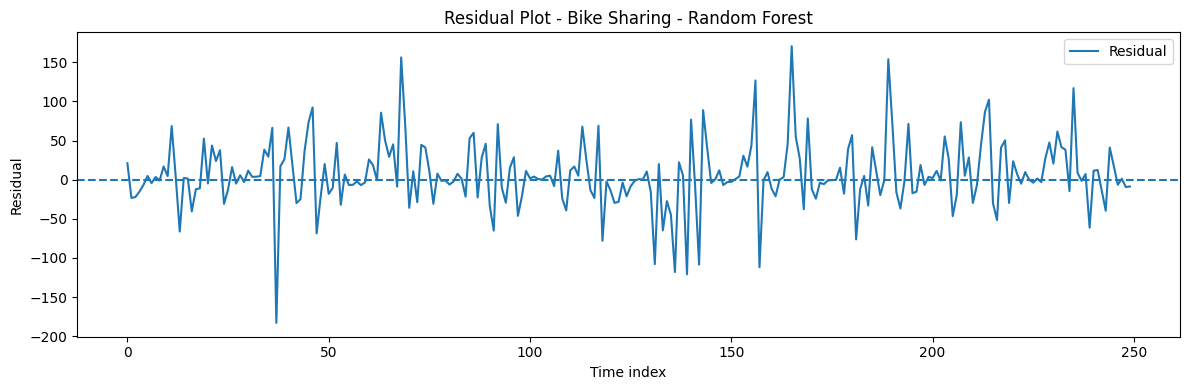

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_random_forest_residual.png


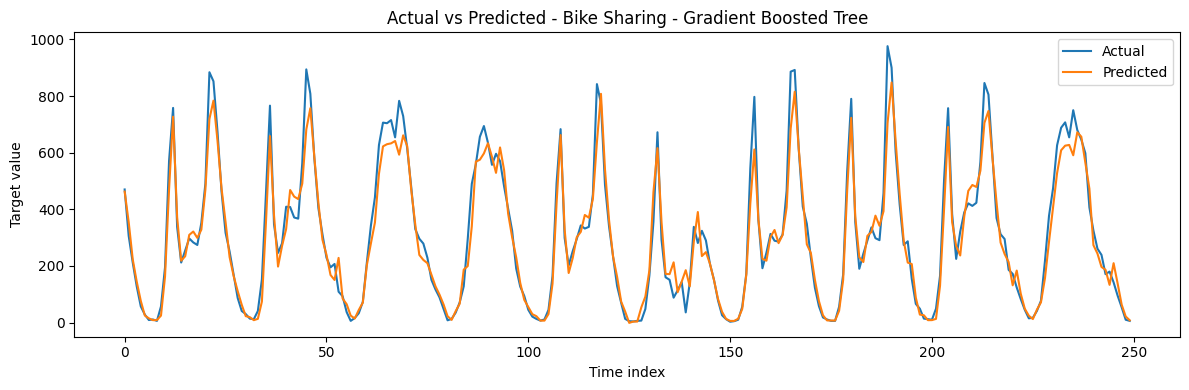

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_gradient_boosted_tree_actual_vs_predicted.png


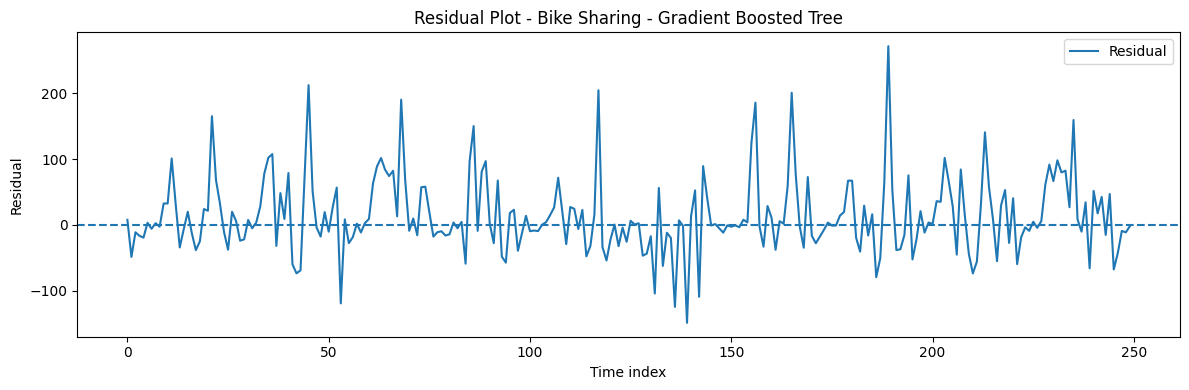

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_gradient_boosted_tree_residual.png


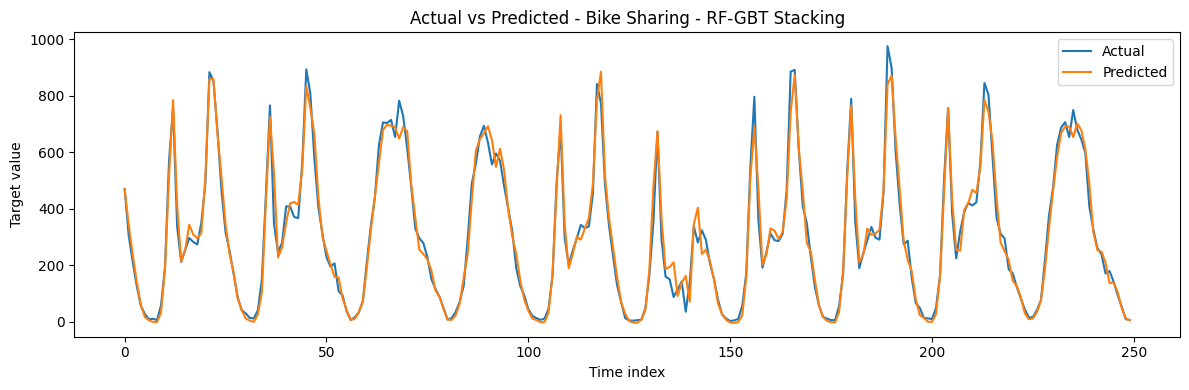

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_rf_gbt_stacking_actual_vs_predicted.png


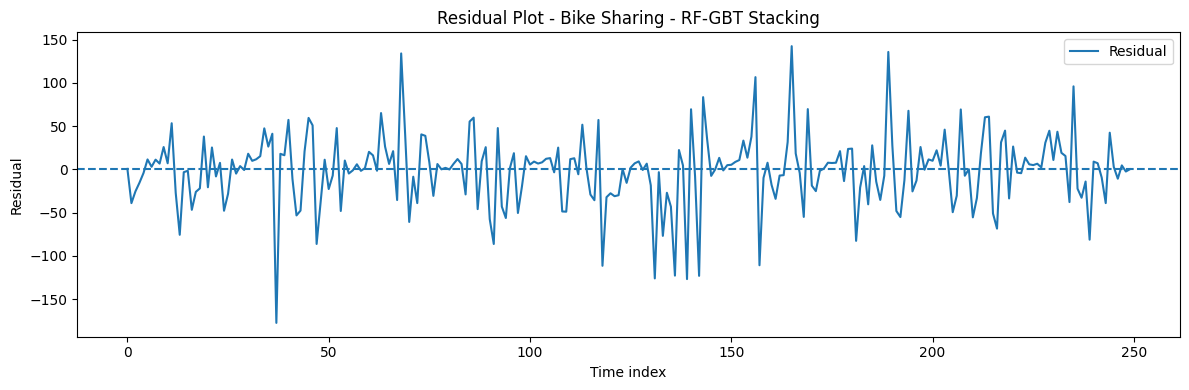

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_rf_gbt_stacking_residual.png


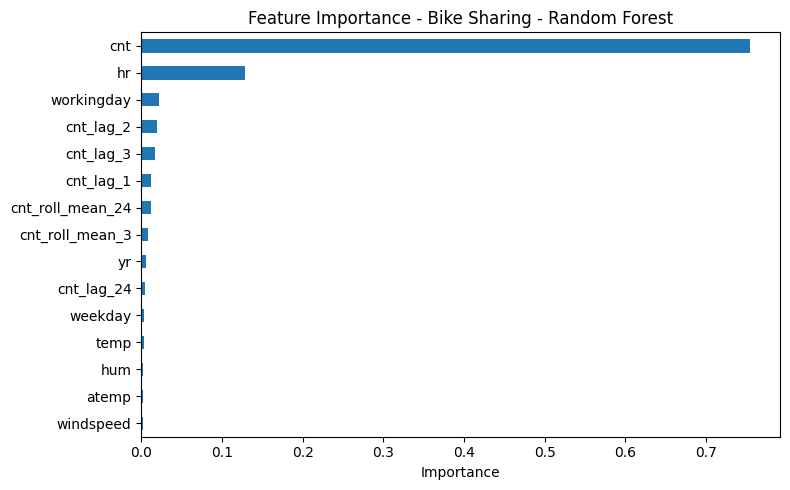

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_random_forest_feature_importance.png


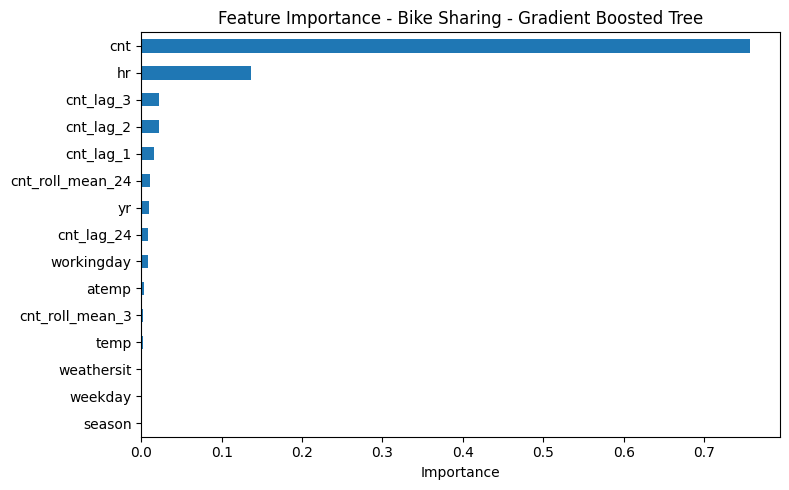

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_gradient_boosted_tree_feature_importance.png


In [ ]:
bike_results, bike_y_test, bike_predictions, bike_models, bike_features = run_experiment(
    bike_df,
    dataset_name='Bike Sharing',
    target_col='target_next',
    exclude_cols=['datetime']
)

## 9. Chạy thực nghiệm trên Air Quality


Dataset: Air Quality
Số dòng train/val/test: 5354 1147 1148
Số features: 22


,Dataset,Model,MAE,RMSE,R2,Fit time (s)
0,Air Quality,Random Forest,0.381568,0.552939,0.812218,29.132262
1,Air Quality,Gradient Boosted Tree,0.386163,0.556693,0.809660,10.375178
2,Air Quality,RF-GBT Stacking,0.370753,0.546661,0.816458,71.726100


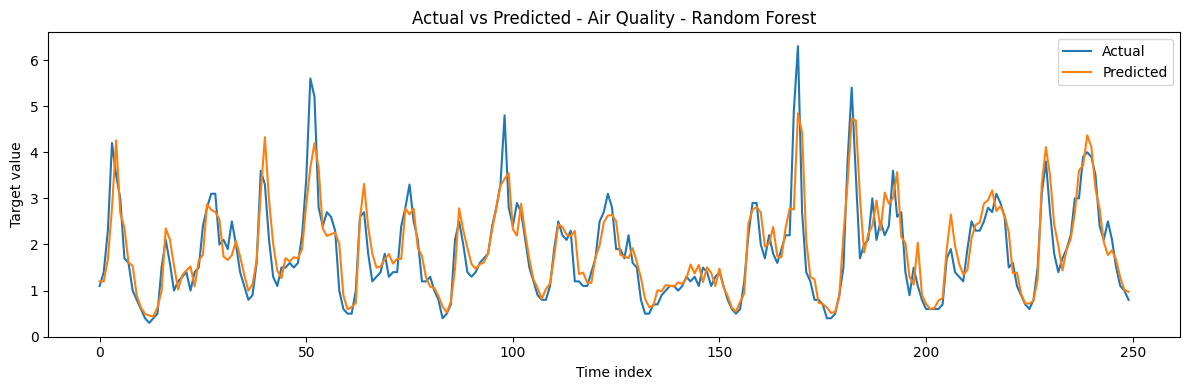

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_random_forest_actual_vs_predicted.png


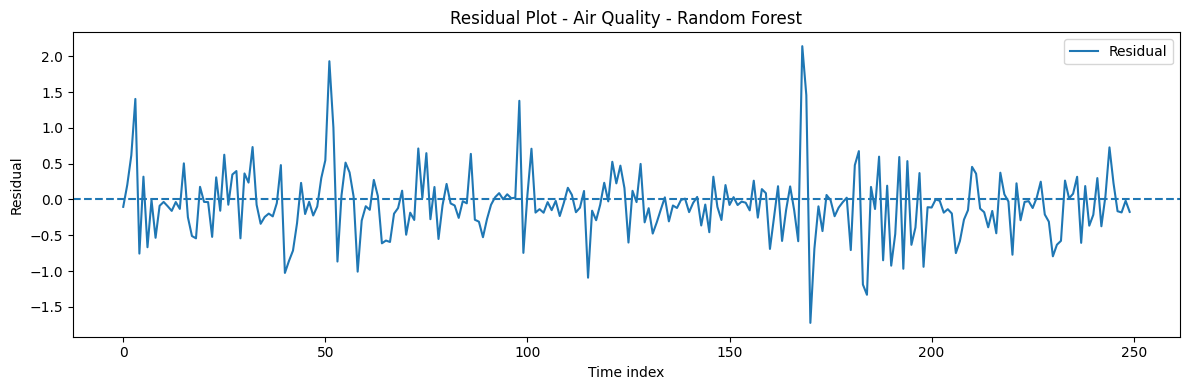

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_random_forest_residual.png


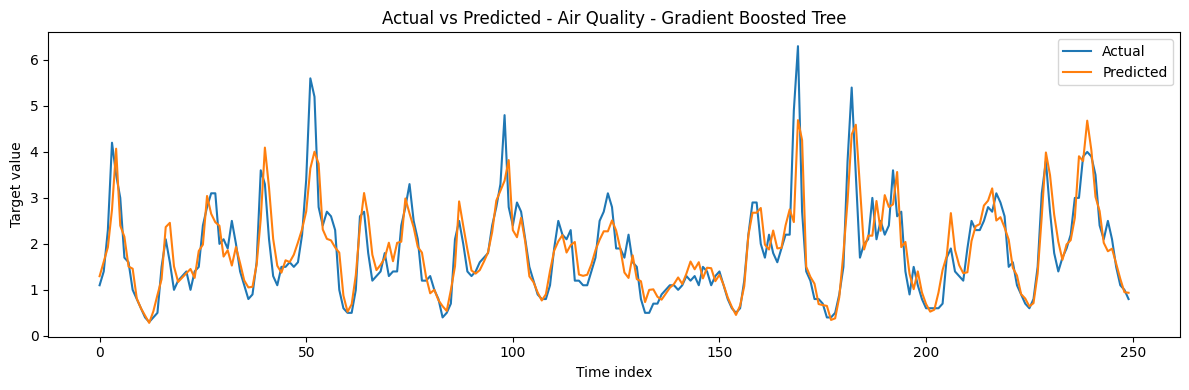

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_gradient_boosted_tree_actual_vs_predicted.png


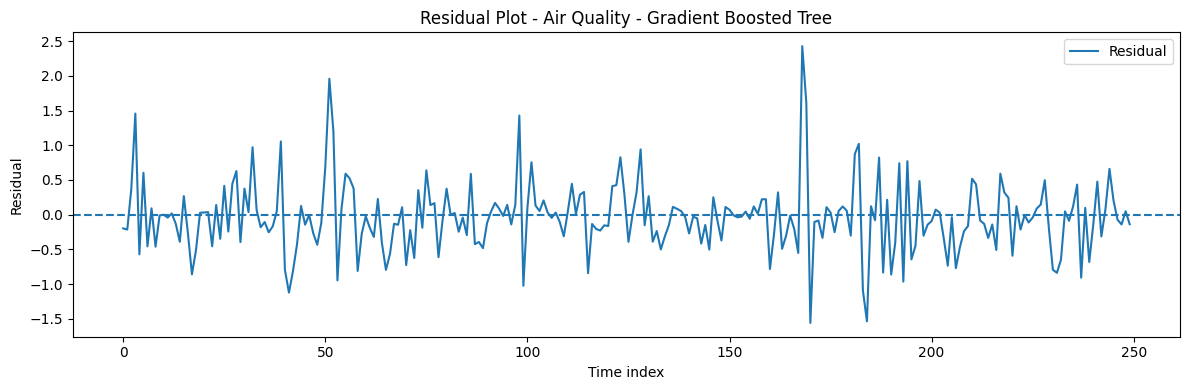

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_gradient_boosted_tree_residual.png


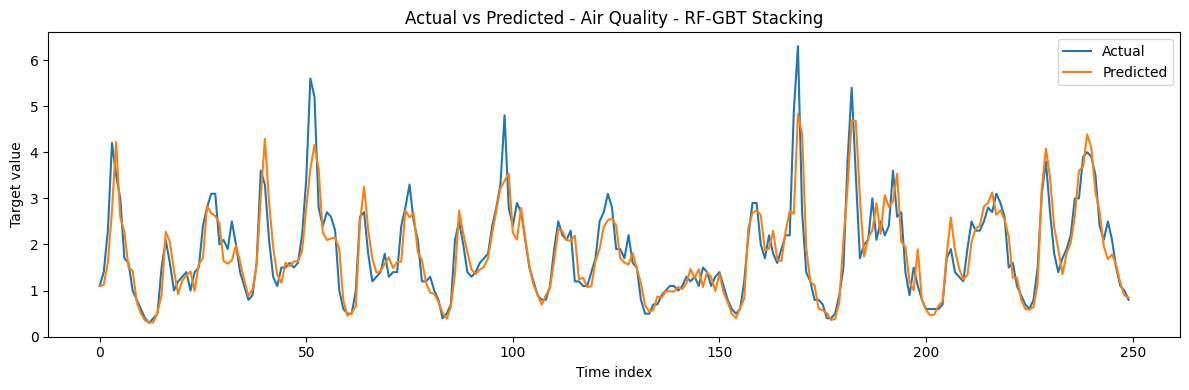

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_rf_gbt_stacking_actual_vs_predicted.png


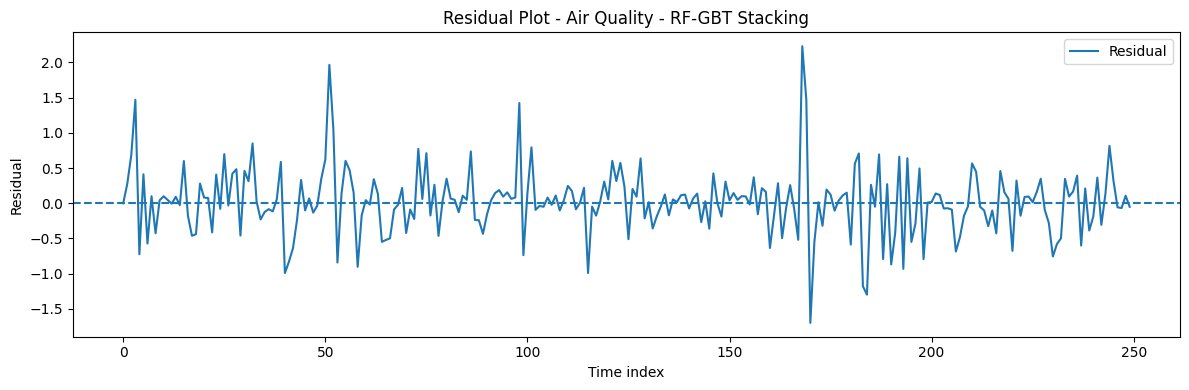

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_rf_gbt_stacking_residual.png


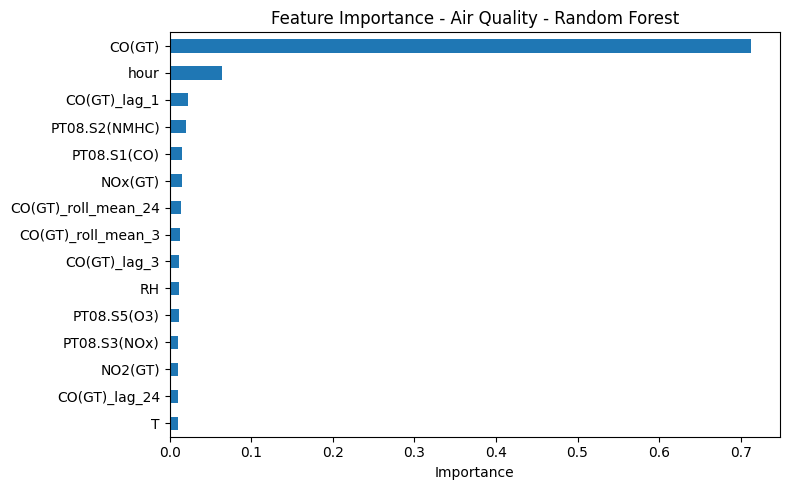

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_random_forest_feature_importance.png


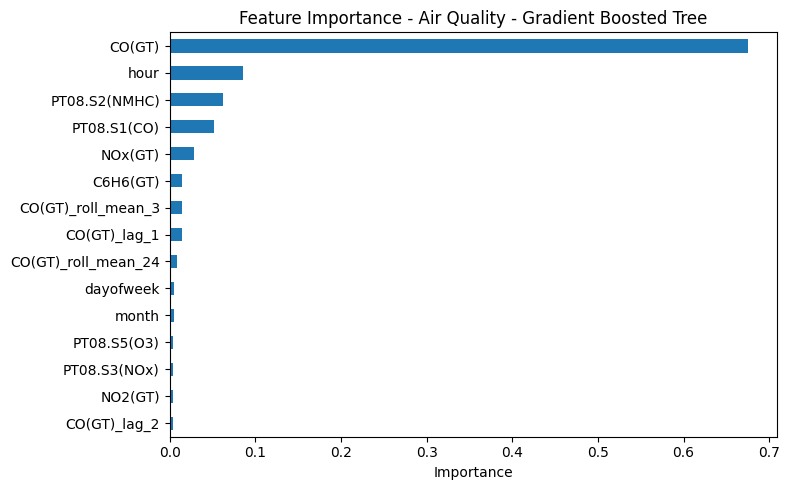

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_gradient_boosted_tree_feature_importance.png


In [ ]:
air_results, air_y_test, air_predictions, air_models, air_features = run_experiment(
    air_df,
    dataset_name='Air Quality',
    target_col='target_next',
    exclude_cols=['Date', 'Time', 'datetime']
)

## 10. Tổng hợp kết quả và vẽ biểu đồ so sánh metrics

Bảng cuối cùng gồm 6 dòng:

- 3 mô hình trên Bike Sharing.
- 3 mô hình trên Air Quality.

Đã lưu bảng kết quả: hw1_rf_gbt_stacking/results/metrics_summary.csv


,Dataset,Model,MAE,RMSE,R2,Fit time (s)
0,Bike Sharing,Random Forest,27.378685,45.735348,0.954395,62.179266
1,Bike Sharing,Gradient Boosted Tree,34.449464,53.006898,0.938741,13.237331
2,Bike Sharing,RF-GBT Stacking,28.255780,46.205964,0.953452,109.665990
3,Air Quality,Random Forest,0.381568,0.552939,0.812218,29.132262
4,Air Quality,Gradient Boosted Tree,0.386163,0.556693,0.809660,10.375178
5,Air Quality,RF-GBT Stacking,0.370753,0.546661,0.816458,71.726100


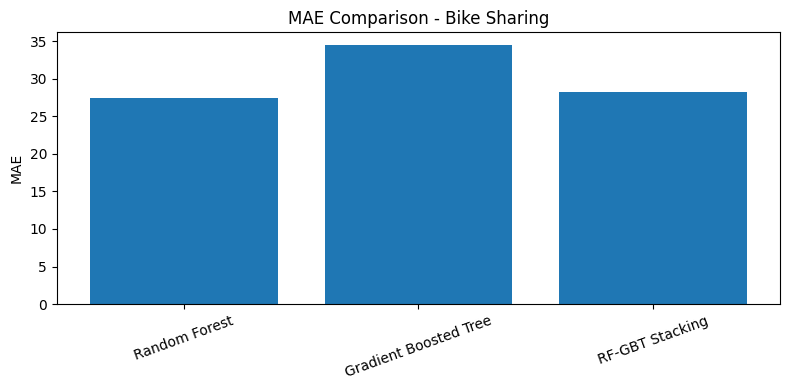

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_mae_comparison.png


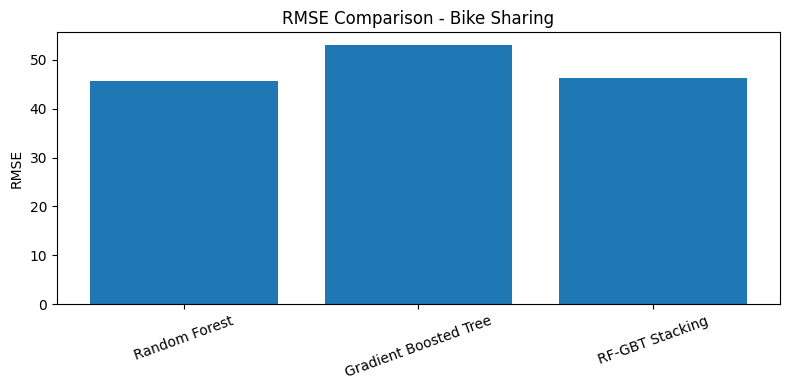

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_rmse_comparison.png


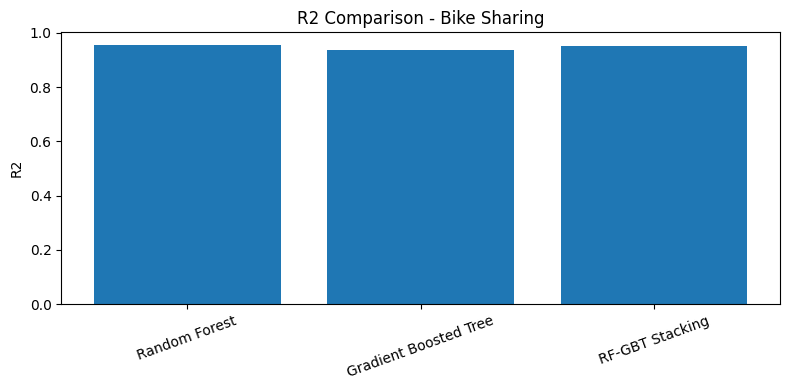

Đã lưu: hw1_rf_gbt_stacking/results/figures/bike_sharing_r2_comparison.png


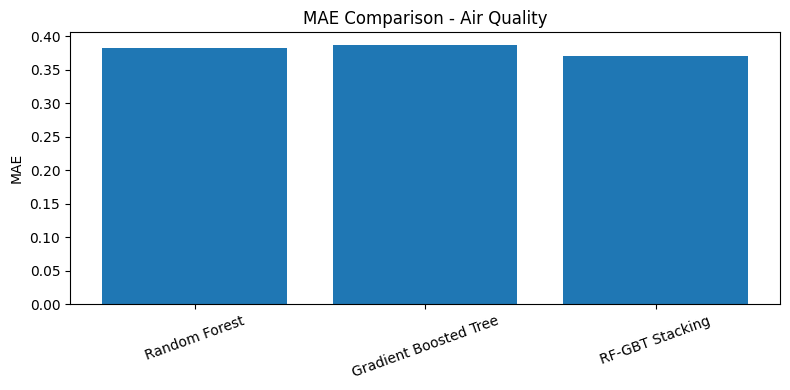

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_mae_comparison.png


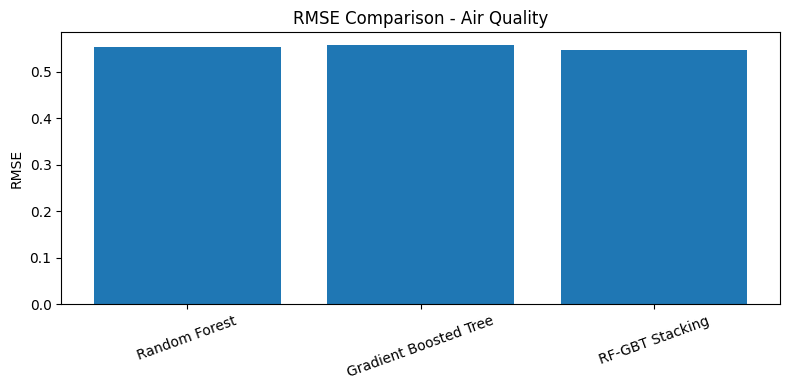

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_rmse_comparison.png


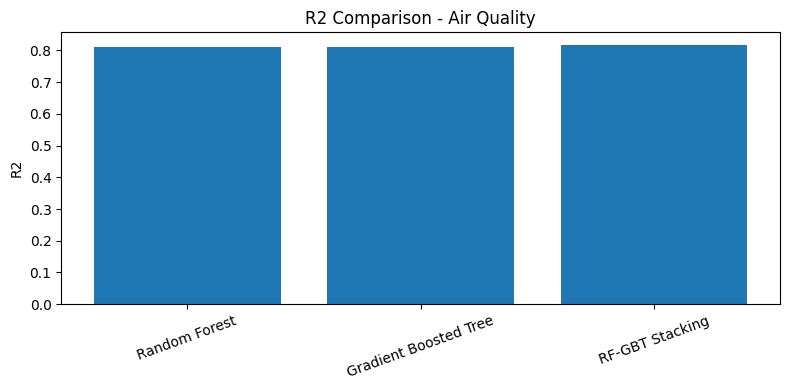

Đã lưu: hw1_rf_gbt_stacking/results/figures/air_quality_r2_comparison.png


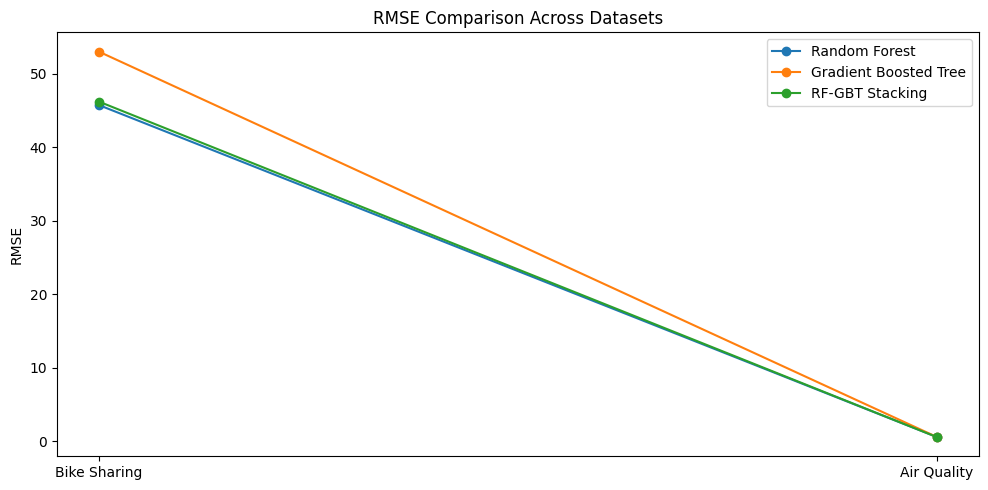

Đã lưu: hw1_rf_gbt_stacking/results/figures/rmse_comparison_across_datasets.png


In [ ]:
all_results = pd.concat([bike_results, air_results], ignore_index=True)
all_results_path = RESULTS_DIR / 'metrics_summary.csv'
all_results.to_csv(all_results_path, index=False)
print('Đã lưu bảng kết quả:', all_results_path)
display(all_results)

# Vẽ metric comparison riêng từng dataset
for dataset_name in all_results['Dataset'].unique():
    for metric in ['MAE', 'RMSE', 'R2']:
        plot_metric_bars(all_results, dataset_name, metric)

# Vẽ một hình RMSE tổng hợp cả hai dataset
plt.figure(figsize=(10, 5))
for model_name in all_results['Model'].unique():
    sub = all_results[all_results['Model'] == model_name]
    plt.plot(sub['Dataset'], sub['RMSE'], marker='o', label=model_name)
plt.title('RMSE Comparison Across Datasets')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
path = FIG_DIR / 'rmse_comparison_across_datasets.png'
plt.savefig(path, dpi=300)
plt.show()
print('Đã lưu:', path)

## 11. Tính phần trăm cải thiện của RF-GBT Stacking

Công thức:

\[
Improvement(\%) = \frac{RMSE_{best\ baseline} - RMSE_{stacking}}{RMSE_{best\ baseline}} \times 100
\]

Nếu kết quả dương, Stacking tốt hơn baseline tốt nhất. Nếu âm, Stacking chưa cải thiện so với baseline tốt nhất.

In [ ]:
for dataset_name in all_results['Dataset'].unique():
    sub = all_results[all_results['Dataset'] == dataset_name]
    best_baseline_rmse = sub[sub['Model'].isin(['Random Forest', 'Gradient Boosted Tree'])]['RMSE'].min()
    stacking_rmse = sub[sub['Model'] == 'RF-GBT Stacking']['RMSE'].iloc[0]
    improvement = (best_baseline_rmse - stacking_rmse) / best_baseline_rmse * 100
    print(f'{dataset_name}: Stacking cải thiện RMSE {improvement:.2f}% so với baseline tốt nhất.')

Bike Sharing: Stacking cải thiện RMSE -1.03% so với baseline tốt nhất.
Air Quality: Stacking cải thiện RMSE 1.14% so với baseline tốt nhất.


## 12. Liệt kê figures đã tạo

Cell này giúp kiểm tra notebook đã tạo đủ figures riêng cho từng mô hình chưa.

In [ ]:
figure_files = sorted(FIG_DIR.glob('*.png'))
print('Số figure đã tạo:', len(figure_files))
for f in figure_files:
    print('-', f)

Số figure đã tạo: 23
- hw1_rf_gbt_stacking/results/figures/air_quality_gradient_boosted_tree_actual_vs_predicted.png
- hw1_rf_gbt_stacking/results/figures/air_quality_gradient_boosted_tree_feature_importance.png
- hw1_rf_gbt_stacking/results/figures/air_quality_gradient_boosted_tree_residual.png
- hw1_rf_gbt_stacking/results/figures/air_quality_mae_comparison.png
- hw1_rf_gbt_stacking/results/figures/air_quality_r2_comparison.png
- hw1_rf_gbt_stacking/results/figures/air_quality_random_forest_actual_vs_predicted.png
- hw1_rf_gbt_stacking/results/figures/air_quality_random_forest_feature_importance.png
- hw1_rf_gbt_stacking/results/figures/air_quality_random_forest_residual.png
- hw1_rf_gbt_stacking/results/figures/air_quality_rf_gbt_stacking_actual_vs_predicted.png
- hw1_rf_gbt_stacking/results/figures/air_quality_rf_gbt_stacking_residual.png
- hw1_rf_gbt_stacking/results/figures/air_quality_rmse_comparison.png
- hw1_rf_gbt_stacking/results/figures/bike_sharing_gradient_boosted_tree_ac

## 13. Nén kết quả để tải về

Sau khi chạy xong notebook, cell này nén thư mục `results/` thành file ZIP để tải về và đưa vào GitHub/báo cáo.

In [ ]:
zip_path = BASE_DIR / 'hw1_results_figures.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file in RESULTS_DIR.rglob('*'):
        if file.is_file():
            zf.write(file, file.relative_to(BASE_DIR))
print('Đã tạo file ZIP:', zip_path)

# Trên Colab có thể tải file này bằng files.download nếu muốn:
# from google.colab import files
# files.download(str(zip_path))

Đã tạo file ZIP: hw1_rf_gbt_stacking/hw1_results_figures.zip
